# Nimbalyst Jupyter integration demo

This notebook is designed to exercise the Nimbalyst Jupyter extension as a real `.ipynb` custom editor. It includes markdown cells, executable Python cells, rich MIME output, and a deliberately bulky output cell so the extension's AI projection tool can show why notebook-aware context matters.

## What to verify in Nimbalyst

- Opening this file should use the **Notebook** custom editor contributed by `com.nimbalyst.jupyter`.
- The file tree should show the notebook icon registered for `*.ipynb` files.
- The notebook should preserve cell IDs, metadata, source, execution counts, and outputs when saved.
- The AI tool `jupyter.get_notebook_projection` should summarize outputs instead of sending raw output blobs to the model.

In [1]:
runs = [31, 35, 29, 41, 33]
print("Nimbalyst notebook smoke test")
print(f"Runs completed: {len(runs)}")
print(f"Average latency: {sum(runs) / len(runs):.1f} ms")
print(f"Best latency: {min(runs)} ms")
print(f"Worst latency: {max(runs)} ms")
print("Status: custom editor data survived nbformat round-trip")

Nimbalyst notebook smoke test
Runs completed: 5
Average latency: 33.8 ms
Best latency: 29 ms
Worst latency: 41 ms
Status: custom editor data survived nbformat round-trip


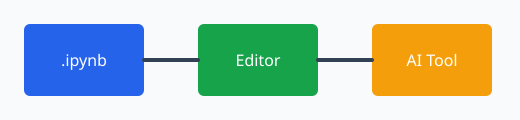

In [2]:
from IPython.display import HTML, SVG, display

display(HTML("""
<div style="font-family: system-ui; border: 1px solid #c7d2fe; padding: 12px; border-radius: 6px; max-width: 520px;">
  <strong>Nimbalyst rich output</strong>
  <p style="margin: 8px 0 0;">This HTML block is stored in the notebook output and should render through the JupyterLab MIME renderer inside the custom editor.</p>
</div>
"""))

display(SVG("""
<svg xmlns="http://www.w3.org/2000/svg" width="520" height="120" viewBox="0 0 520 120">
  <rect width="520" height="120" fill="#f8fafc"/>
  <rect x="24" y="24" width="120" height="72" rx="6" fill="#2563eb"/>
  <rect x="198" y="24" width="120" height="72" rx="6" fill="#16a34a"/>
  <rect x="372" y="24" width="120" height="72" rx="6" fill="#f59e0b"/>
  <path d="M144 60h54M318 60h54" stroke="#334155" stroke-width="4" stroke-linecap="round"/>
  <text x="84" y="66" text-anchor="middle" font-family="system-ui" font-size="16" fill="white">.ipynb</text>
  <text x="258" y="66" text-anchor="middle" font-family="system-ui" font-size="16" fill="white">Editor</text>
  <text x="432" y="66" text-anchor="middle" font-family="system-ui" font-size="16" fill="white">AI Tool</text>
</svg>
"""))

In [3]:
for row in range(1, 21):
    print(f"row {row:03d}: {'*' * 80}")

row 001: ********************************************************************************
row 002: ********************************************************************************
row 003: ********************************************************************************
row 004: ********************************************************************************
row 005: ********************************************************************************
row 006: ********************************************************************************
row 007: ********************************************************************************
row 008: ********************************************************************************
row 009: ********************************************************************************
row 010: ********************************************************************************
row 011: ********************************************************************************
row 012: *

## AI projection behavior

When the Nimbalyst AI integration reads this notebook through `jupyter.get_notebook_projection`, the agent should still see every cell's source. The long stdout, HTML, and SVG output payloads should be replaced by compact placeholders such as `[stdout hidden: ...]`, `[text/html hidden: ...]`, and `[image/svg+xml hidden: ...]`.